# ML Algorithm Advisor

**Objective:** Build a simple recommendation model that suggests a suitable machine learning algorithm based on dataset characteristics.

In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## Load Dataset

In [2]:
data = pd.read_csv("algorithm_dataset.csv")
data.head()

,DataType,ProblemType,DatasetSize,Explainability,Speed,Algorithm
0,Tabular,Classification,Small,Yes,Yes,Decision Tree
1,Tabular,Classification,Small,Yes,No,Decision Tree
2,Tabular,Classification,Small,No,Yes,Random Forest
3,Tabular,Classification,Small,No,No,Random Forest
4,Tabular,Classification,Medium,Yes,Yes,Random Forest


## Dataset Information

In [3]:
data.info()
data.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   DataType        200 non-null    str  
 1   ProblemType     200 non-null    str  
 2   DatasetSize     200 non-null    str  
 3   Explainability  200 non-null    str  
 4   Speed           200 non-null    str  
 5   Algorithm       200 non-null    str  
dtypes: str(6)
memory usage: 9.5 KB


,DataType,ProblemType,DatasetSize,Explainability,Speed,Algorithm
count,200,200,200,200,200,200
unique,5,2,3,2,2,14
top,Tabular,Classification,Small,Yes,Yes,CNN
freq,48,104,68,100,100,48


## Encode Categorical Columns

In [4]:
encoders={}
for col in data.columns:
    le=LabelEncoder()
    data[col]=le.fit_transform(data[col])
    encoders[col]=le

X=data.drop("Algorithm",axis=1)
y=data["Algorithm"]

## Split Dataset

In [5]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

## Train Decision Tree Model

In [6]:
model=DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## Evaluate Model

In [7]:
pred=model.predict(X_test)
acc=accuracy_score(y_test,pred)
print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 100.00%


## Feature Importance

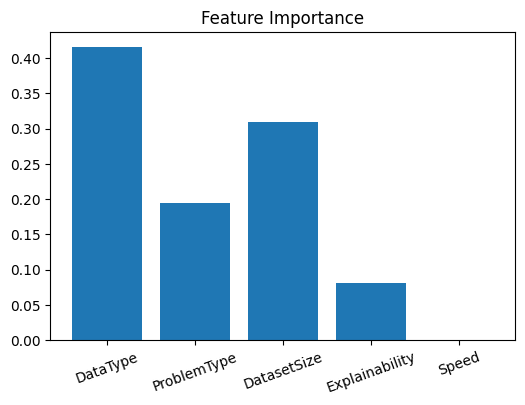

In [8]:
import matplotlib.pyplot as plt

importance=model.feature_importances_
plt.figure(figsize=(6,4))
plt.bar(X.columns,importance)
plt.xticks(rotation=20)
plt.title("Feature Importance")
plt.show()

## Test With Sample Input

In [9]:
sample=pd.DataFrame({
    "DataType":["Tabular"],
    "ProblemType":["Classification"],
    "DatasetSize":["Medium"],
    "Explainability":["Yes"],
    "Speed":["No"]
})

for col in sample.columns:
    sample[col]=encoders[col].transform(sample[col])

prediction=model.predict(sample)
print("Recommended Algorithm:",
      encoders["Algorithm"].inverse_transform(prediction)[0])

Recommended Algorithm: Random Forest


## Save Model

In [10]:
joblib.dump(model,"model.pkl")
joblib.dump(encoders,"encoders.pkl")
print("Model saved successfully.")

Model saved successfully.


## Conclusion
The Decision Tree model was trained on encoded dataset characteristics and can recommend a suitable machine learning algorithm for new datasets. The trained model is saved for use in the Streamlit application.